In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [18]:
A, B, N = -np.pi, np.pi, 100
x = np.linspace(A, B, N)
upsample_factors = [2, 4, 10]

In [19]:
def f1(x):
    return np.sin(x)


def f2(x):
    return np.sin(x**-1)


def f3(x):
    return np.sign(np.sin(8*x))

In [20]:
def h1(t):
    return np.where((t >= 0) & (t < 1), 1, 0)


def h2(t):
    return np.where((t >= -1/2) & (t < 1/2), 1, 0)


def h3(t):
    return np.where((t >= -1) & (t <= 1), 1 - abs(t), 0)


def h4(t):
    return np.sinc(t / np.pi)  # https://numpy.org/doc/stable/reference/generated/numpy.sinc.html#numpy.sinc


kernels = [h1, h2, h3, h4]

## Podpunk 1 i 2

MSE for h1: 0.11653723527228642
MSE for h2: 0.0018978179900959193
MSE for h3: 0.0046309961506191015
MSE for h4: 0.14554584385877195


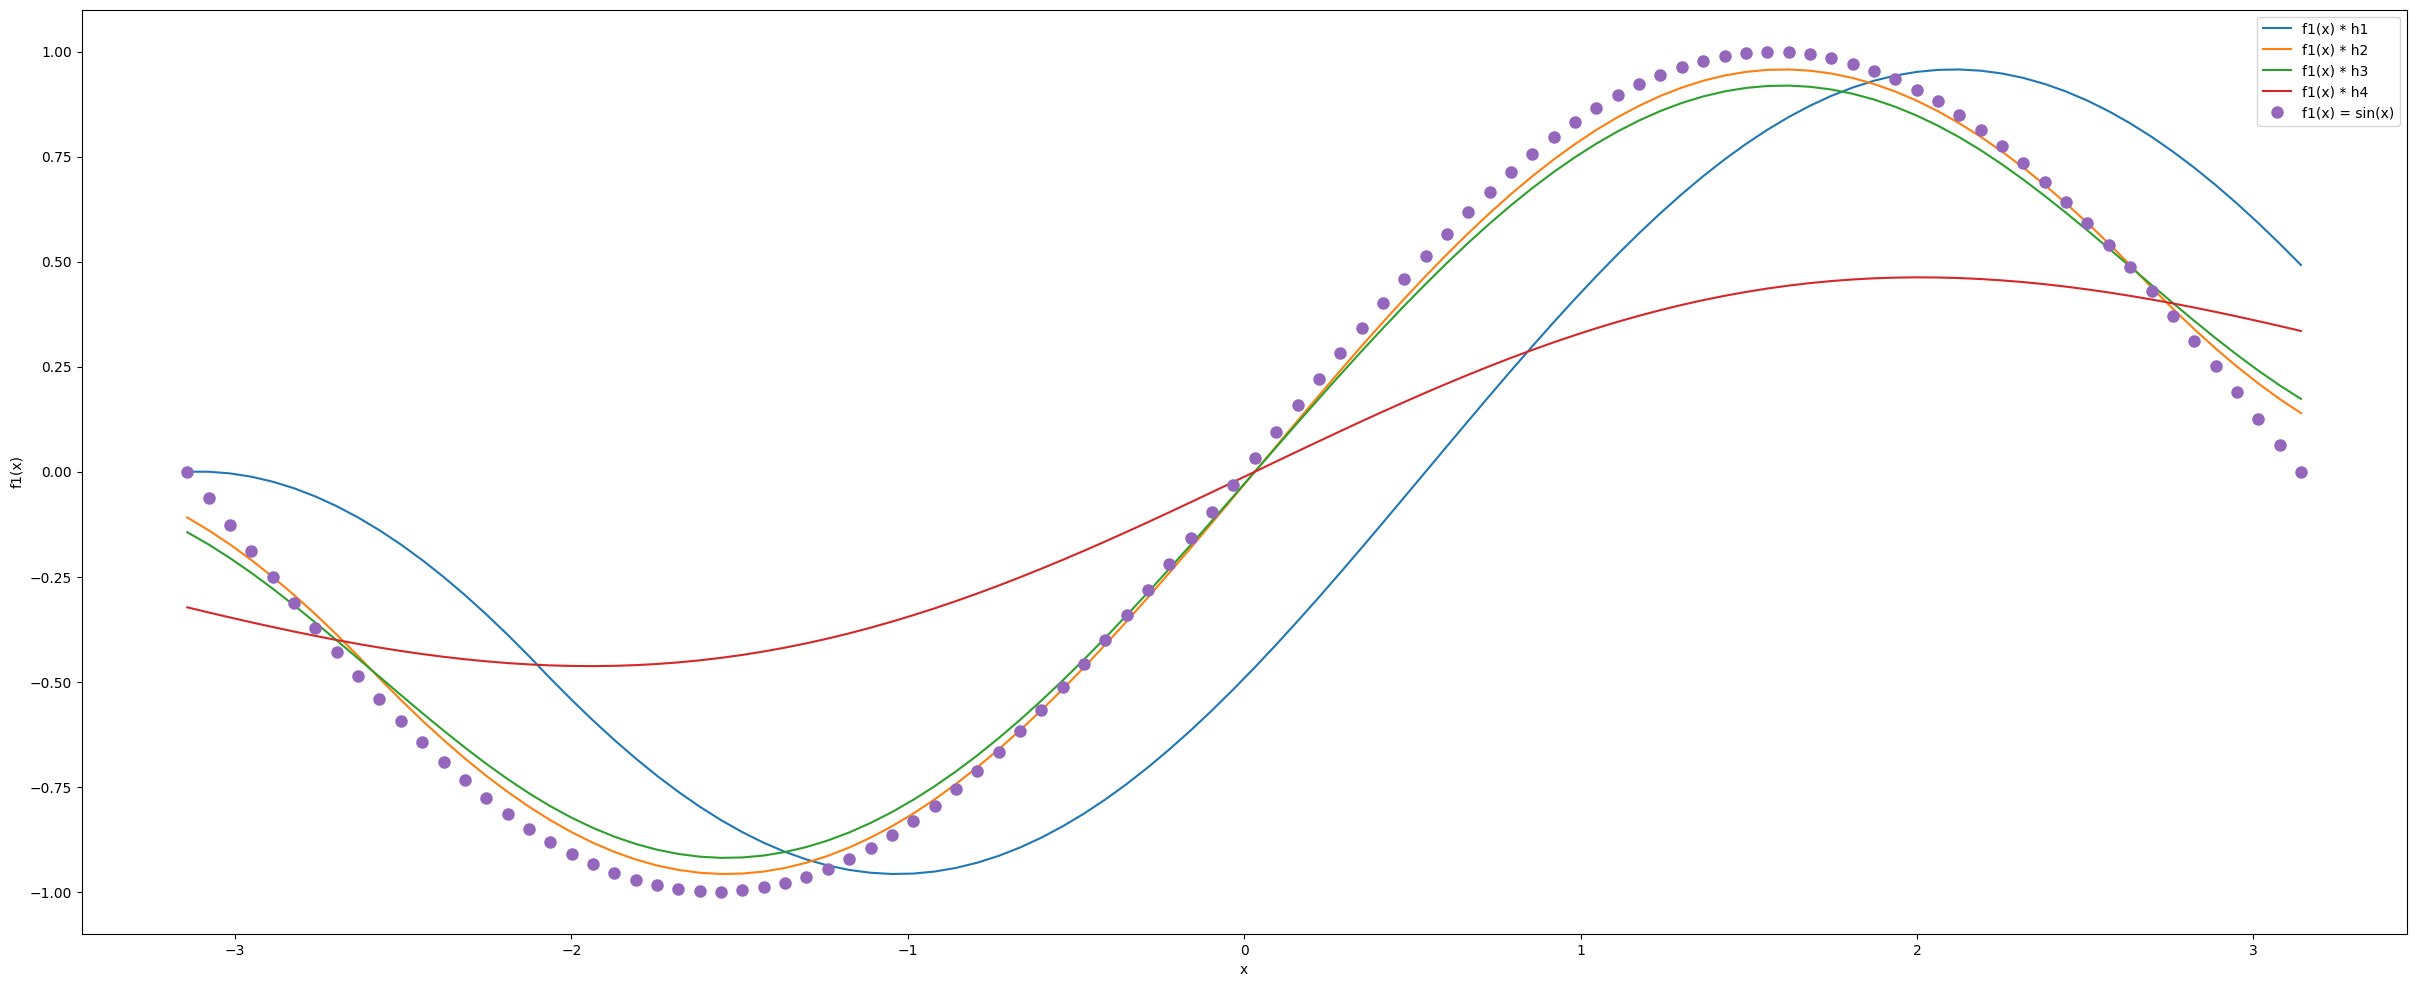

In [21]:
y1 = f1(x)

plt.figure(figsize=(30, 12))

for h in kernels:
    y1_conv = np.convolve(y1, h(x) / np.sum(h(x)), mode='same')
    mse = mean_squared_error(y1, y1_conv)
    print(f'MSE for {h.__name__}: {mse}')
    plt.plot(x, y1_conv, label=f'f1(x) * {h.__name__}')

plt.plot(x, y1, 'o', label='f1(x) = sin(x)', markersize=8)
plt.xlabel('x')
plt.ylabel('f1(x)')

plt.legend()
plt.show()


MSE for h1: 0.17054799346281882
MSE for h2: 0.08682418230038763
MSE for h3: 0.07833516140338367
MSE for h4: 0.18508272579697008


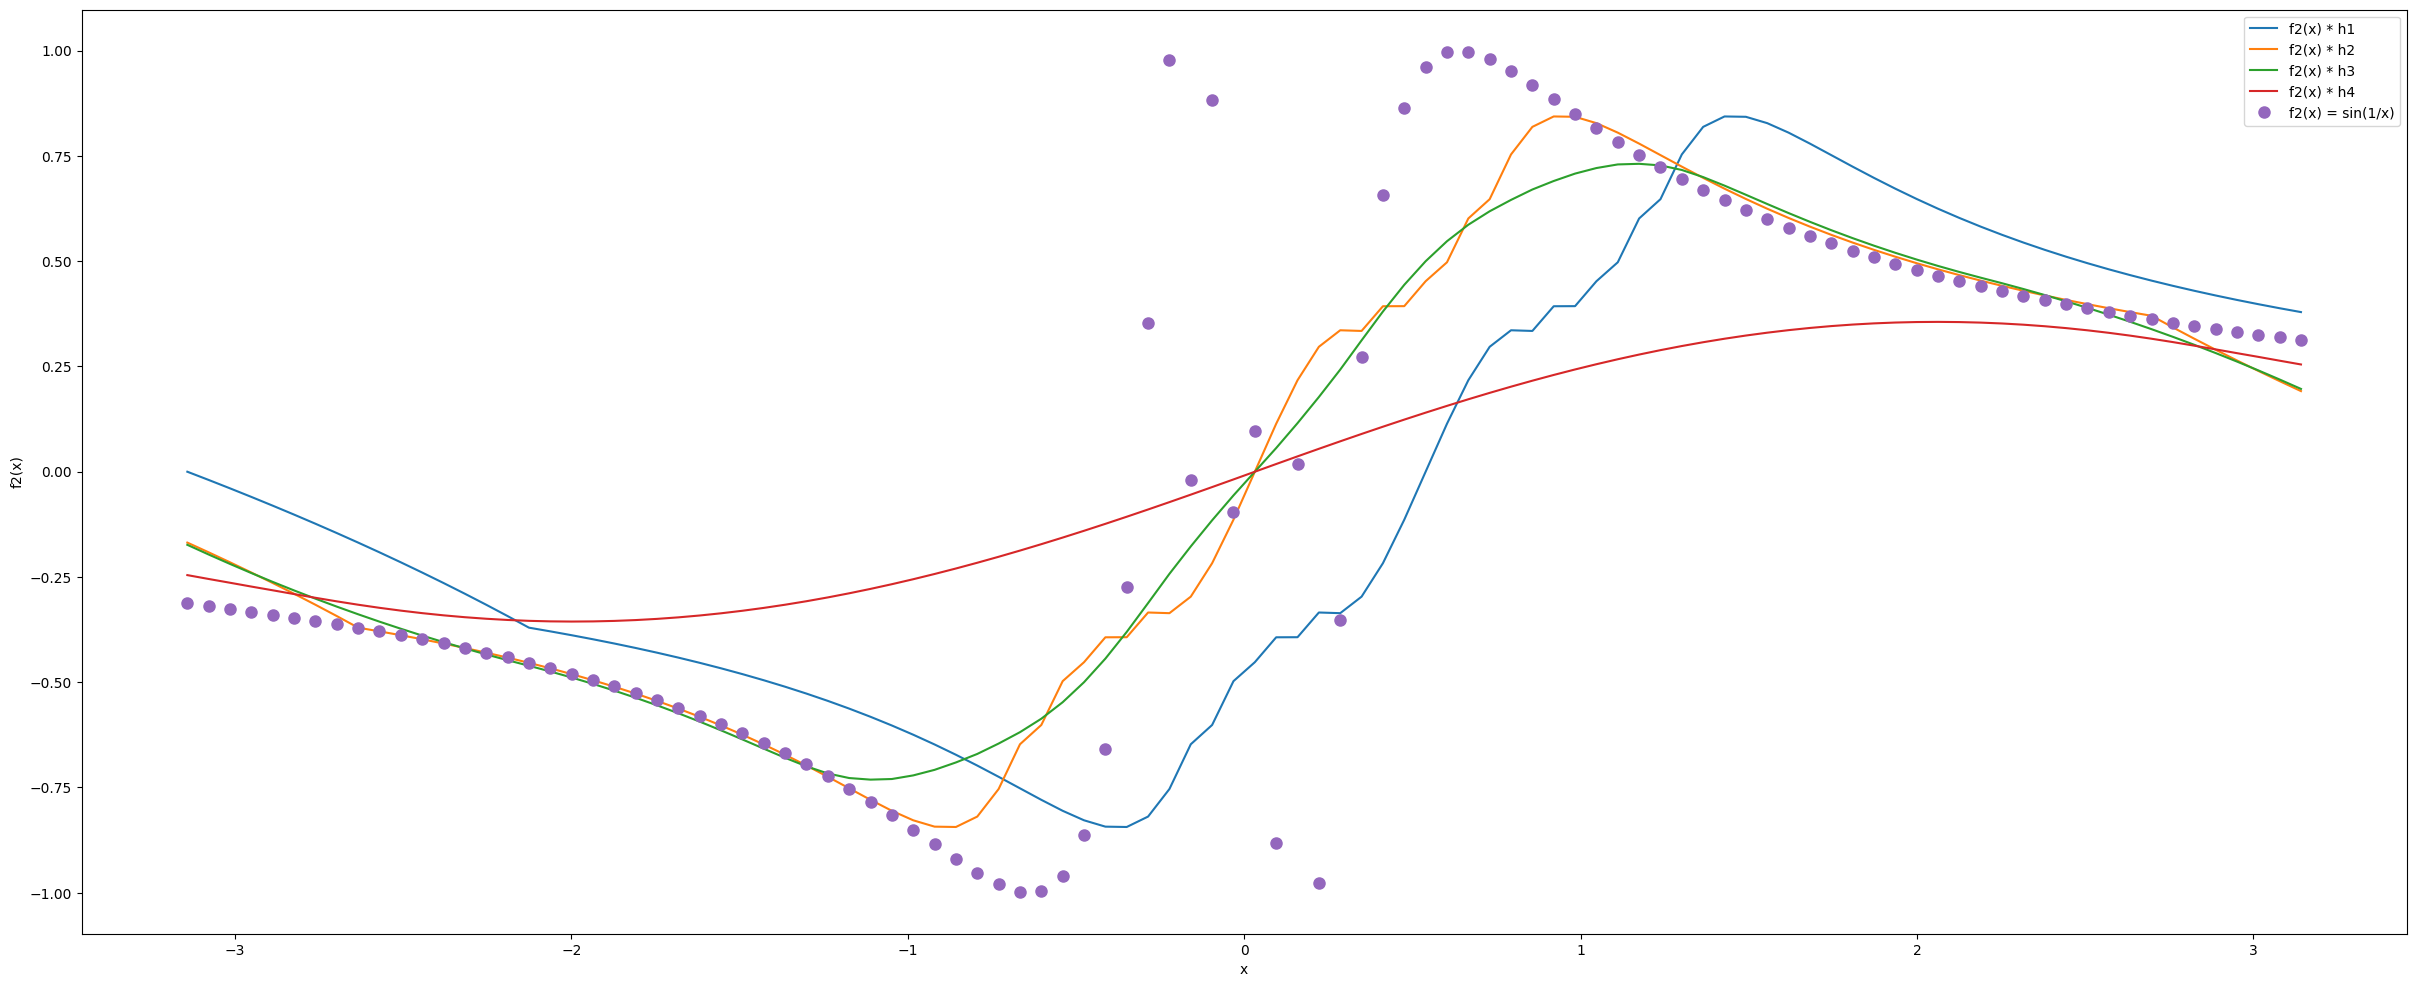

In [22]:
y2 = f2(x)

plt.figure(figsize=(30, 12))

for h in kernels:
    y2_conv = np.convolve(y2, h(x) / np.sum(h(x)), mode='same')
    mse = mean_squared_error(y2, y2_conv)
    print(f'MSE for {h.__name__}: {mse}')
    plt.plot(x, y2_conv, label=f'f2(x) * {h.__name__}')

plt.plot(x, y2, 'o', label='f2(x) = sin(1/x)', markersize=8)
plt.xlabel('x')
plt.ylabel('f2(x)')

plt.legend()
plt.show()


MSE for h1: 0.93484375
MSE for h2: 1.26265625
MSE for h3: 0.9171761563810463
MSE for h4: 0.9942819709639024


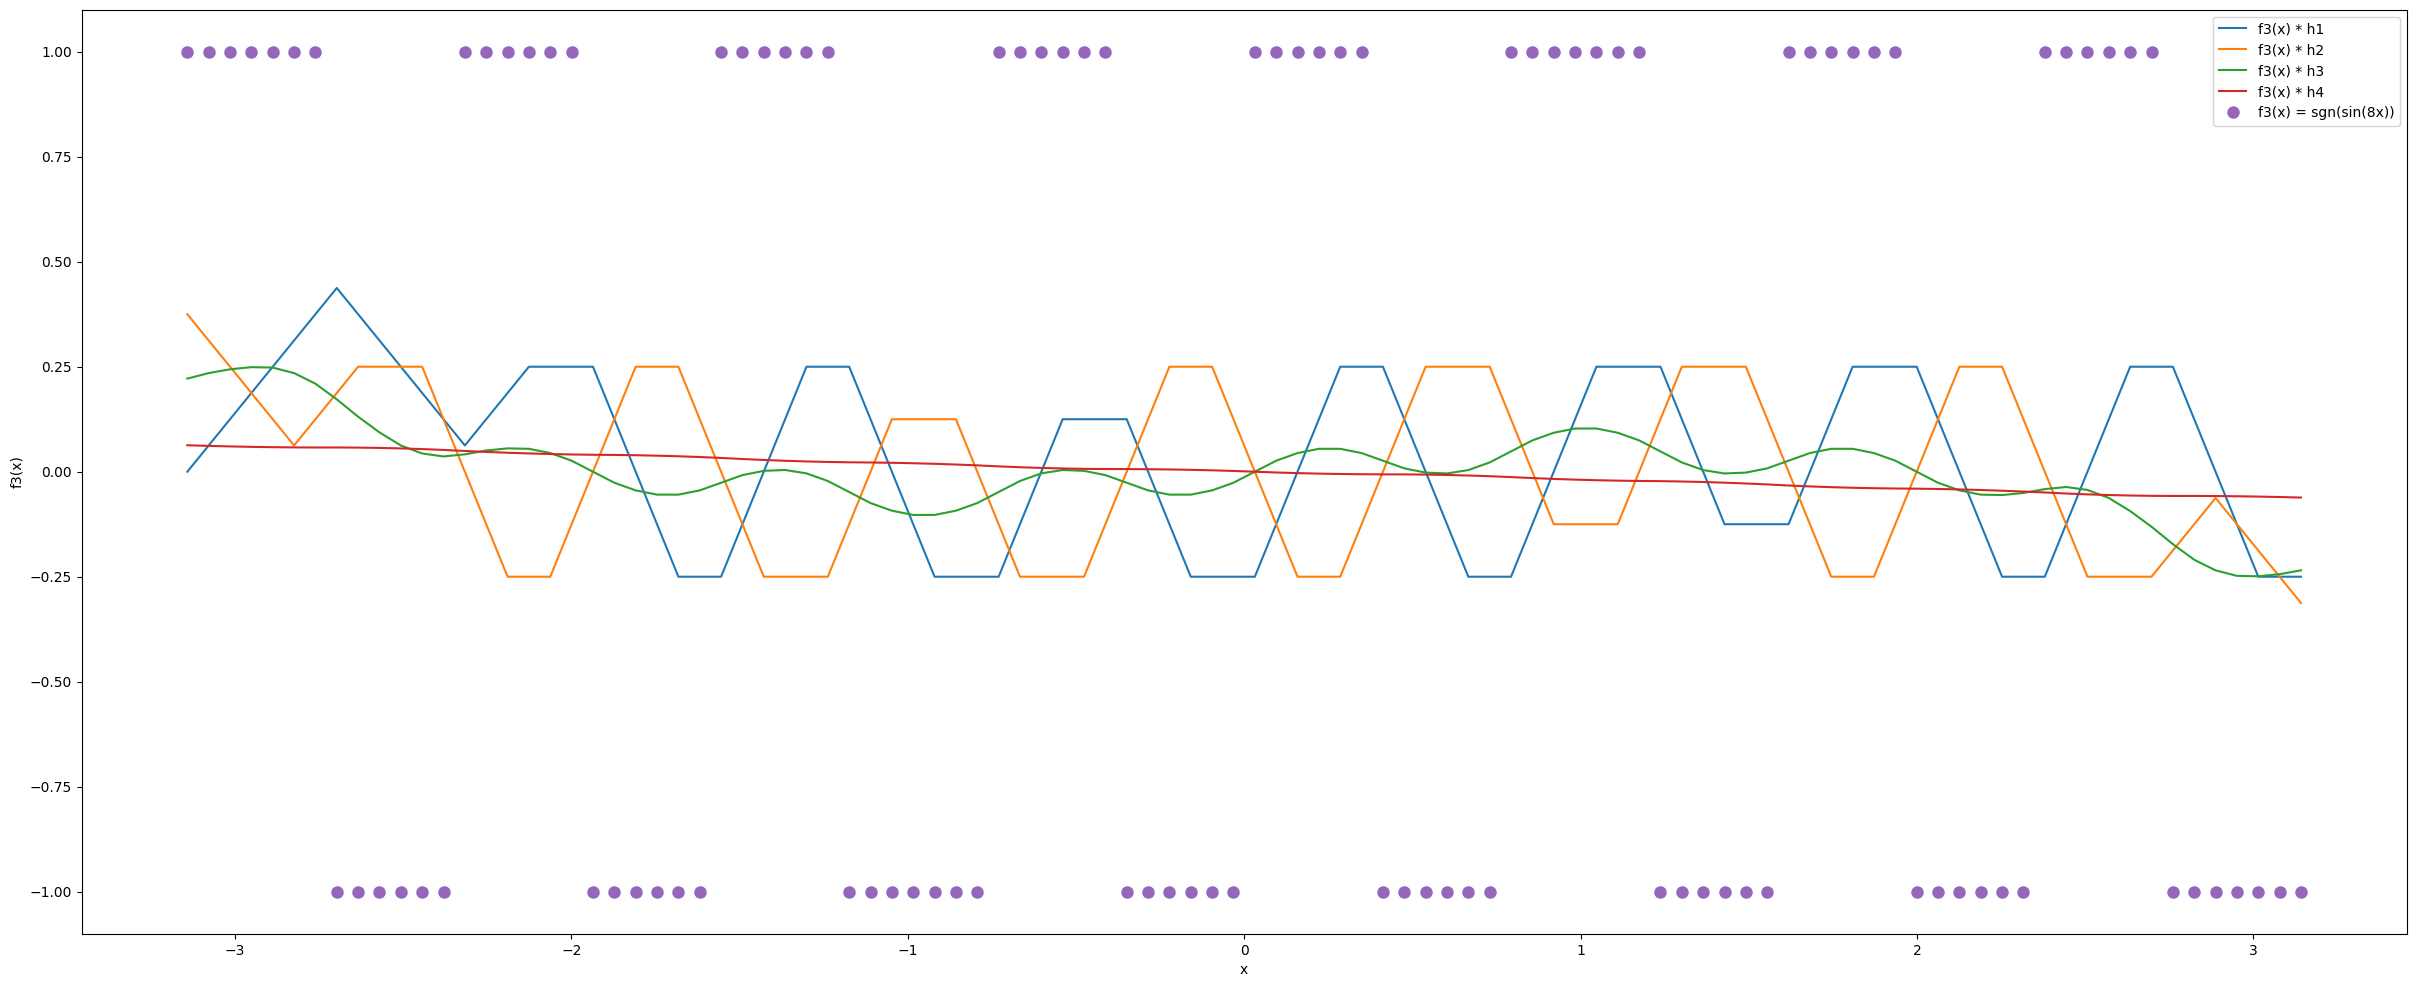

In [23]:
y3 = f3(x)

plt.figure(figsize=(30, 12))

for h in kernels:
    y3_conv = np.convolve(y3, h(x) / np.sum(h(x)), mode='same')
    mse = mean_squared_error(y3, y3_conv)
    print(f'MSE for {h.__name__}: {mse}')
    plt.plot(x, y3_conv, label=f'f3(x) * {h.__name__}')

plt.plot(x, y3, 'o', label='f3(x) = sgn(sin(8x))', markersize=8)
plt.xlabel('x')
plt.ylabel('f3(x)')

plt.legend()
plt.show()


## Podpunkt 3

In [24]:
for L in upsample_factors:
    x_up = np.linspace(A, B, N * L)
    y1_up = f1(x_up)

    for h in kernels:
        y1_up_conv = np.convolve(y1_up, h(x_up) / np.sum(h(x_up)), mode='same')
        mse = mean_squared_error(y1_up, y1_up_conv)
        print(f'f1 * {h.__name__} MSE for {L=}: {mse}')
    print()

f1 * h1 MSE for L=2: 0.10923363947081154
f1 * h2 MSE for L=2: 0.0014841444638428094
f1 * h3 MSE for L=2: 0.004215300656896743
f1 * h4 MSE for L=2: 0.14560192877757483

f1 * h1 MSE for L=4: 0.10569227786875203
f1 * h2 MSE for L=4: 0.001358400158049472
f1 * h3 MSE for L=4: 0.004086194125184509
f1 * h4 MSE for L=4: 0.14566293519066437

f1 * h1 MSE for L=10: 0.10249157876893182
f1 * h2 MSE for L=10: 0.0012525363597584833
f1 * h3 MSE for L=10: 0.004034821218767046
f1 * h4 MSE for L=10: 0.14571000817603186



In [25]:
for L in upsample_factors:
    x_up = np.linspace(A, B, N * L)
    y2_up = f2(x_up)

    for h in kernels:
        y2_up_conv = np.convolve(y2_up, h(x_up) / np.sum(h(x_up)), mode='same')
        mse = mean_squared_error(y2_up, y2_up_conv)
        print(f'f2 * {h.__name__} MSE for {L=}: {mse}')
    print()

f2 * h1 MSE for L=2: 0.160720269945855
f2 * h2 MSE for L=2: 0.07356666734899302
f2 * h3 MSE for L=2: 0.07300838298541325
f2 * h4 MSE for L=2: 0.18437217279340495

f2 * h1 MSE for L=4: 0.17392256187028302
f2 * h2 MSE for L=4: 0.09307634700290421
f2 * h3 MSE for L=4: 0.09034938031058036
f2 * h4 MSE for L=4: 0.20092952125756855

f2 * h1 MSE for L=10: 0.1658806366717232
f2 * h2 MSE for L=10: 0.08712053975969812
f2 * h3 MSE for L=10: 0.08529101601371815
f2 * h4 MSE for L=10: 0.19613966672035343



In [26]:
for L in upsample_factors:
    x_up = np.linspace(A, B, N * L)
    y3_up = f3(x_up)

    for h in kernels:
        y3_up_conv = np.convolve(y3_up, h(x_up) / np.sum(h(x_up)), mode='same')
        mse = mean_squared_error(y3_up, y3_up_conv)
        print(f'f3 * {h.__name__} MSE for {L=}: {mse}')
    print()

f3 * h1 MSE for L=2: 0.8882421875
f3 * h2 MSE for L=2: 1.27408203125
f3 * h3 MSE for L=2: 0.9240748980549879
f3 * h4 MSE for L=2: 0.9920222554288358

f3 * h1 MSE for L=4: 0.8732421875
f3 * h2 MSE for L=4: 1.27956298828125
f3 * h3 MSE for L=4: 0.9282487450163491
f3 * h4 MSE for L=4: 0.9967398153059169

f3 * h1 MSE for L=10: 0.8602034729638858
f3 * h2 MSE for L=10: 1.2694944319820542
f3 * h3 MSE for L=10: 0.9271192637080269
f3 * h4 MSE for L=10: 0.9960046454212722



## Podpunkt 4

In [27]:
x_uniform = np.linspace(A, B, N)
x_random = np.sort(np.random.uniform(A, B, N))
x_normal = np.sort(np.clip(np.random.normal(0, 1, N), A, B))

In [28]:
y1_uniform = f1(x_uniform)
y1_random = f1(x_random)
y1_normal = f1(x_normal)

funcs = [
    ('uniform', x_uniform, y1_uniform),
    ('random', x_random, y1_random),
    ('normal', x_normal, y1_normal)
]

for name, x1, y1 in funcs:
    for h in kernels:
        y1_conv = np.convolve(y1, h(x1) / np.sum(h(x1)), mode='same')
        mse = mean_squared_error(y1, y1_conv)
        print(f'f1({name}) * {h.__name__} MSE: {mse}')
    print()


f1(uniform) * h1 MSE: 0.11653723527228642
f1(uniform) * h2 MSE: 0.0018978179900959193
f1(uniform) * h3 MSE: 0.0046309961506191015
f1(uniform) * h4 MSE: 0.14554584385877195

f1(random) * h1 MSE: 0.010168398399750683
f1(random) * h2 MSE: 0.0689763101137626
f1(random) * h3 MSE: 0.04889858180699076
f1(random) * h4 MSE: 0.16214022223810962

f1(normal) * h1 MSE: 0.21257627294159387
f1(normal) * h2 MSE: 0.03838856151600427
f1(normal) * h3 MSE: 0.05831399389875463
f1(normal) * h4 MSE: 0.1721285299326931



In [29]:
y2_uniform = f2(x_uniform)
y2_random = f2(x_random)
y2_normal = f2(x_normal)

funcs = [
    ('uniform', x_uniform, y2_uniform),
    ('random', x_random, y2_random),
    ('normal', x_normal, y2_normal)
]

for name, x2, y2 in funcs:
    for h in kernels:
        y2_conv = np.convolve(y2, h(x2) / np.sum(h(x2)), mode='same')
        mse = mean_squared_error(y2, y2_conv)
        print(f'f2({name}) * {h.__name__} MSE: {mse}')
    print()



f2(uniform) * h1 MSE: 0.17054799346281882
f2(uniform) * h2 MSE: 0.08682418230038763
f2(uniform) * h3 MSE: 0.07833516140338367
f2(uniform) * h4 MSE: 0.18508272579697008

f2(random) * h1 MSE: 0.0670144761832978
f2(random) * h2 MSE: 0.11166525841987202
f2(random) * h3 MSE: 0.09948370359345278
f2(random) * h4 MSE: 0.1760524073946609

f2(normal) * h1 MSE: 0.3840178860081902
f2(normal) * h2 MSE: 0.1534824003378837
f2(normal) * h3 MSE: 0.16585231234943784
f2(normal) * h4 MSE: 0.3053091498542378



In [30]:
y3_uniform = f3(x_uniform)
y3_random = f3(x_random)
y3_normal = f3(x_normal)

funcs = [
    ('uniform', x_uniform, y3_uniform),
    ('random', x_random, y3_random),
    ('normal', x_normal, y3_normal)
]

for name, x3, y3 in funcs:
    for h in kernels:
        y3_conv = np.convolve(y3, h(x3) / np.sum(h(x3)), mode='same')
        mse = mean_squared_error(y3, y3_conv)
        print(f'f3({name}) * {h.__name__} MSE: {mse}')
    print()



f3(uniform) * h1 MSE: 0.93484375
f3(uniform) * h2 MSE: 1.26265625
f3(uniform) * h3 MSE: 0.9171761563810463
f3(uniform) * h4 MSE: 0.9942819709639024

f3(random) * h1 MSE: 0.9244444444444446
f3(random) * h2 MSE: 0.9307692307692307
f3(random) * h3 MSE: 0.9689710613176995
f3(random) * h4 MSE: 0.9762212018243194

f3(normal) * h1 MSE: 1.018934802571166
f3(normal) * h2 MSE: 1.1332253086419752
f3(normal) * h3 MSE: 0.9326551645555499
f3(normal) * h4 MSE: 0.9919052277948783



## Podpunkt 5

In [38]:
L = 16
x_dense = np.linspace(A, B, N * L)